In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, 
                             confusion_matrix, 
                             accuracy_score)

print("Libraries loaded")

Libraries loaded


In [2]:
train = pd.read_csv('../data/windows_train.csv')
test  = pd.read_csv('../data/windows_cow04.csv')

print(f"Training set: {len(train):,} windows")
print(f"Test set:     {len(test):,} windows")
print(f"\nColumns: {train.columns.tolist()}")

Training set: 85,978 windows
Test set:     16,867 windows

Columns: ['animal_id', 'window_start', 'x_mean', 'x_std', 'x_min', 'x_max', 'x_range', 'y_mean', 'y_std', 'y_min', 'y_max', 'y_range', 'z_mean', 'z_std', 'z_min', 'z_max', 'z_range', 'magnitude_mean', 'magnitude_std', 'odba_mean', 'odba_std', 'behavior']


In [3]:
feature_cols = [
    'x_mean', 'x_std', 'x_min', 'x_max', 'x_range',
    'y_mean', 'y_std', 'y_min', 'y_max', 'y_range',
    'z_mean', 'z_std', 'z_min', 'z_max', 'z_range',
    'magnitude_mean', 'magnitude_std',
    'odba_mean', 'odba_std'
]

X_train = train[feature_cols]
y_train = train['behavior']

X_test  = test[feature_cols]
y_test  = test['behavior']

print("Training class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
behavior
Other         35317
Ruminating    33330
Eating        17331
Name: count, dtype: int64

Test class distribution:
behavior
Other         7872
Ruminating    6136
Eating        2859
Name: count, dtype: int64


In [4]:
print("Training Random Forest classifier...")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,        # use all CPU cores
    class_weight='balanced'  # handles class imbalance
)

rf.fit(X_train, y_train)
print("Training complete")

Training Random Forest classifier...
Training complete


In [5]:
y_pred = rf.predict(X_test)

print("=== Classification Report (tested on cow_04) ===\n")
print(classification_report(y_test, y_pred, 
                            target_names=['Eating', 'Other', 'Ruminating']))

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

=== Classification Report (tested on cow_04) ===

              precision    recall  f1-score   support

      Eating       0.51      0.75      0.61      2859
       Other       0.87      0.78      0.82      7872
  Ruminating       0.80      0.72      0.76      6136

    accuracy                           0.75     16867
   macro avg       0.72      0.75      0.73     16867
weighted avg       0.78      0.75      0.76     16867

Overall Accuracy: 0.7535


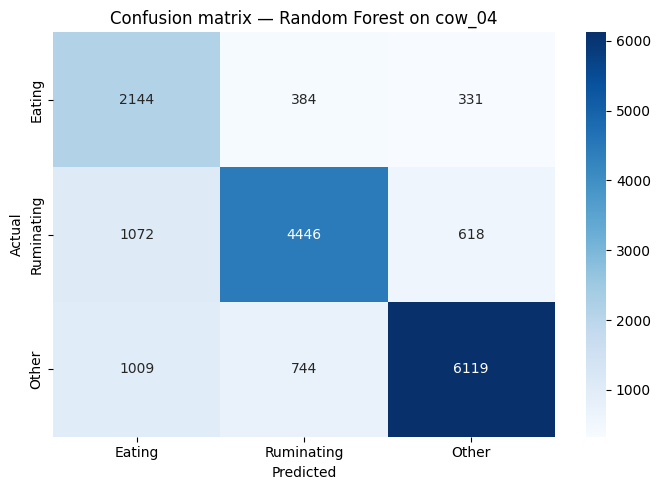

In [6]:
cm = confusion_matrix(y_test, y_pred, 
                      labels=['Eating', 'Ruminating', 'Other'])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Eating', 'Ruminating', 'Other'],
            yticklabels=['Eating', 'Ruminating', 'Other'],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix — Random Forest on cow_04')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=100)
plt.show()

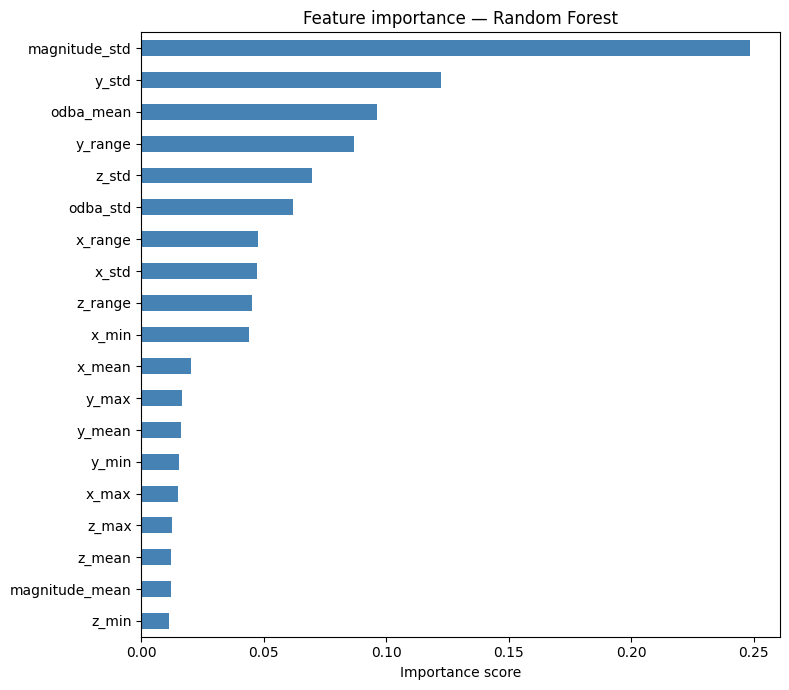


Top 5 most important features:
magnitude_std    0.248227
y_std            0.122453
odba_mean        0.096329
y_range          0.086860
z_std            0.069840
dtype: float64


In [7]:
importances = pd.Series(rf.feature_importances_, 
                         index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature importance — Random Forest')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=100)
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5))

In [8]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/rf_classifier.joblib')
joblib.dump(feature_cols, '../models/feature_cols.joblib')

print("Model saved to ../models/rf_classifier.joblib")
print(f"Features saved: {feature_cols}")

Model saved to ../models/rf_classifier.joblib
Features saved: ['x_mean', 'x_std', 'x_min', 'x_max', 'x_range', 'y_mean', 'y_std', 'y_min', 'y_max', 'y_range', 'z_mean', 'z_std', 'z_min', 'z_max', 'z_range', 'magnitude_mean', 'magnitude_std', 'odba_mean', 'odba_std']


In [9]:
# The weak eating detection is likely because eating involves 
# a characteristic head-down posture that changes y_mean significantly
# Let's check mean y value per behavior for cow_04

print("Mean Y value per behavior (cow_04):")
print(test.groupby('behavior')['y_mean'].mean().round(2))

print("\nMean magnitude per behavior (cow_04):")
print(test.groupby('behavior')['magnitude_mean'].mean().round(2))

print("\nMean ODBA per behavior (cow_04):")
print(test.groupby('behavior')['odba_mean'].mean().round(2))

Mean Y value per behavior (cow_04):
behavior
Eating        903.28
Other         777.70
Ruminating    932.90
Name: y_mean, dtype: float64

Mean magnitude per behavior (cow_04):
behavior
Eating        1015.97
Other         1018.20
Ruminating    1018.34
Name: magnitude_mean, dtype: float64

Mean ODBA per behavior (cow_04):
behavior
Eating        407.55
Other         113.75
Ruminating    139.13
Name: odba_mean, dtype: float64
